# ✍️ Handwritten Character Recognition

### CodeAlpha Machine Learning Internship

**Objective:** Build a Convolutional Neural Network (CNN) to recognize handwritten digits using the MNIST dataset.

**Technology Used:**
- Python
- TensorFlow
- Keras
- NumPy
- Matplotlib

## 1. Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

## 2. Load the MNIST Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## 3. Explore the Dataset

Each MNIST image is a 28 × 28 pixel grayscale image representing a handwritten digit from 0 to 9.

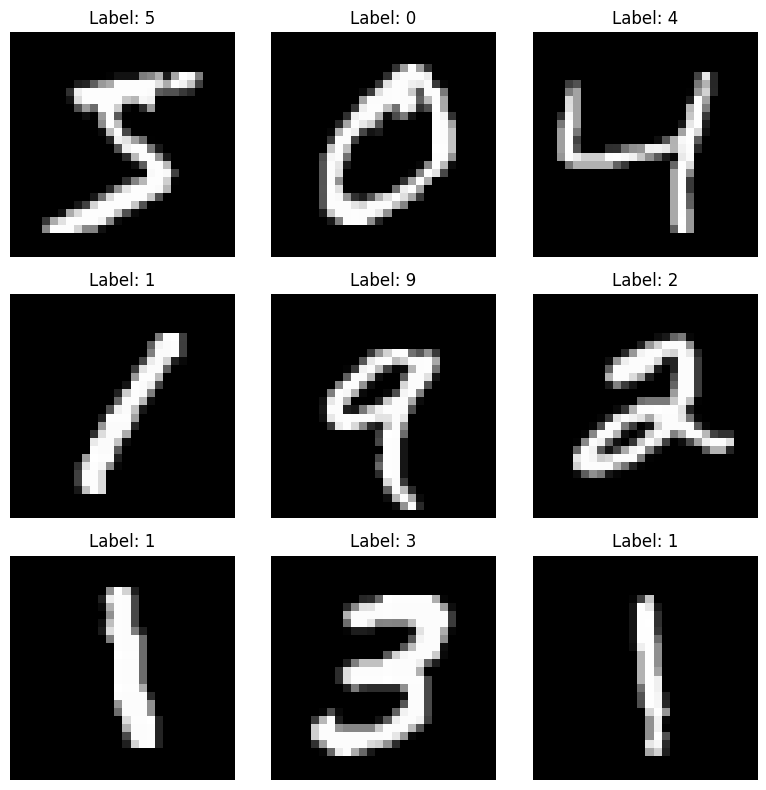

In [ ]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

The pixel values of MNIST images range from 0 to 255.

We normalize the pixel values to a range of 0 to 1 so that the neural network can learn more efficiently.

We also reshape the images to include the grayscale channel required by the CNN.

In [ ]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add the channel dimension for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


## 5. Build the Convolutional Neural Network

A CNN is well suited for image recognition because it can learn important patterns and features from images.

The model will contain:
- Convolutional layers to detect image features
- Max Pooling layers to reduce the image dimensions
- Flatten layer to convert the features into a one-dimensional vector
- Dense layers for classification

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile the Model

The model is compiled using:
- Adam optimizer for updating the model weights
- Sparse categorical crossentropy as the loss function
- Accuracy to measure classification performance

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


## 7. Train the CNN Model

The CNN is trained using the MNIST training dataset.

During training, the model learns patterns from the handwritten digit images and their corresponding labels.

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - accuracy: 0.9507 - loss: 0.1667 - val_accuracy: 0.9858 - val_loss: 0.0529
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9839 - loss: 0.0518 - val_accuracy: 0.9848 - val_loss: 0.0523
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9889 - loss: 0.0359 - val_accuracy: 0.9877 - val_loss: 0.0426
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9914 - loss: 0.0267 - val_accuracy: 0.9908 - val_loss: 0.0370
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.9931 - loss: 0.0208 - val_accuracy: 0.9907 - val_loss: 0.0348


## 8. Evaluate the Model

The trained CNN is evaluated on the test dataset to measure how accurately it recognizes unseen handwritten digits.

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9917 - loss: 0.0291
Test Loss: 0.029055453836917877
Test Accuracy: 0.9916999936103821


## 9. Training and Validation Accuracy

The following graph shows how the model's accuracy changes across each training epoch.

Training accuracy shows performance on the training data, while validation accuracy shows performance on data that was not used directly for training.

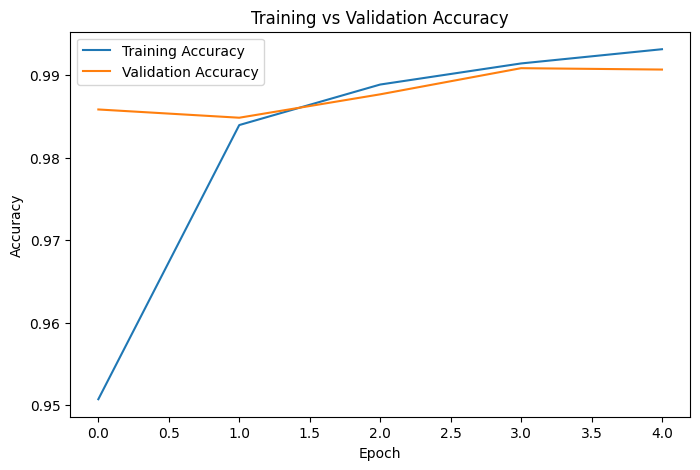

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

## 10. Training and Validation Loss

The loss graph shows how the model's prediction error changes during training.

A decreasing loss generally indicates that the model is learning from the data.

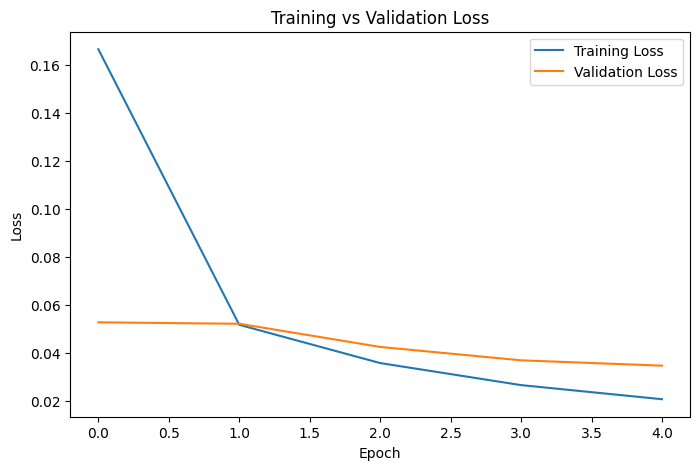

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

## 11. Make Predictions

The trained CNN will predict the digit represented by images from the test dataset.

The predicted digit will be compared with the actual label.

In [ ]:
# Make predictions for the test dataset
predictions = model.predict(x_test)

# Convert probabilities into predicted digit labels
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:", predicted_labels[:10])
print("Actual labels:   ", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Predicted labels: [7 2 1 0 4 1 4 9 5 9]
Actual labels:    [7 2 1 0 4 1 4 9 5 9]


## 12. Visualize Predictions

The following images show the handwritten digits along with the model's predicted labels and the actual labels.

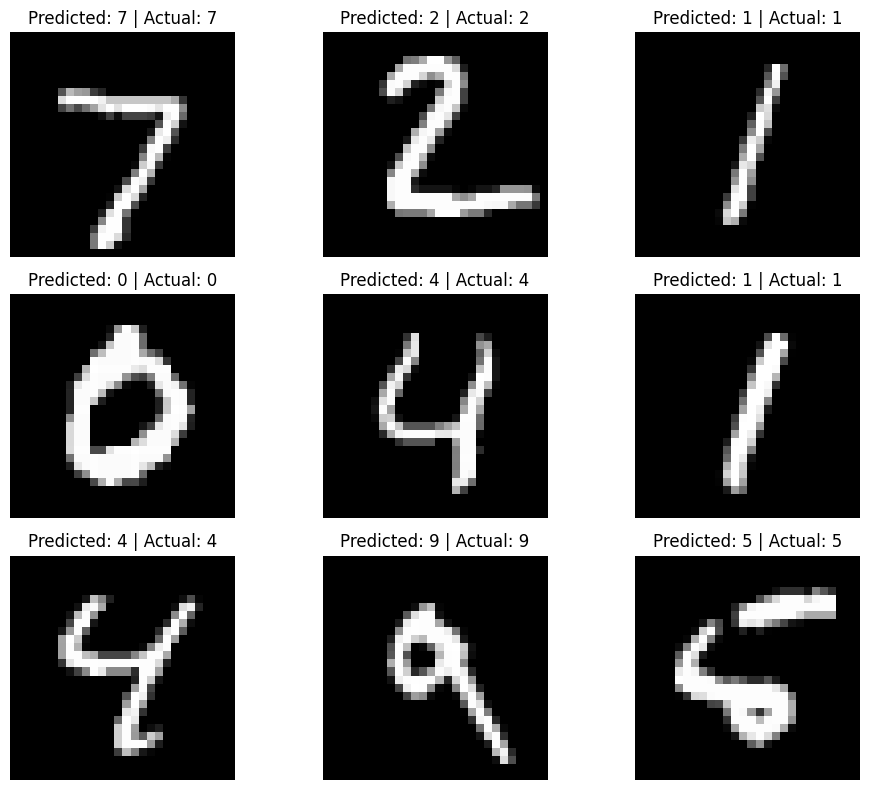

In [ ]:
plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(
        f"Predicted: {predicted_labels[i]} | Actual: {y_test[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Confusion Matrix and Classification Report

A confusion matrix shows the number of correct and incorrect predictions for each digit from 0 to 9.

The classification report provides precision, recall, and F1-score for each digit.

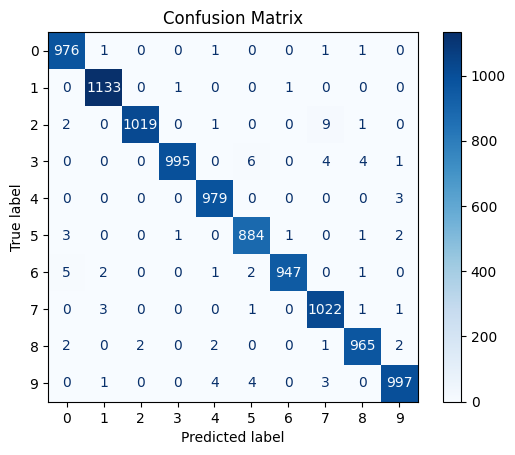

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Generate classification report
report = classification_report(
    y_test,
    predicted_labels
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 14. Save the Trained Model

The trained CNN model is saved in Keras format so that it can be loaded and used later for handwritten digit prediction without retraining the model.

In [ ]:
# Save the trained CNN model
model.save("handwritten_character_recognition.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print("Model file exists:", os.path.exists("handwritten_character_recognition.keras"))

Model file exists: True


## 15. Final Results

The Convolutional Neural Network was trained on the MNIST handwritten digit dataset and evaluated using unseen test data.

### Results

- The model successfully learned patterns from handwritten digit images.
- Test accuracy was measured using the MNIST test dataset.
- A confusion matrix was used to analyze correct and incorrect predictions.
- Precision, recall, and F1-score were calculated for each digit.
- The trained CNN model was saved for future use.

### Conclusion

The CNN successfully performs handwritten digit recognition on the MNIST dataset. The model can identify digits from 0 to 9 based on their handwritten image patterns.

In [ ]:
print("Final Model Performance")
print("-----------------------")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Final Model Performance
-----------------------
Test Accuracy: 99.17%
Test Loss: 0.0291
